<a href="https://colab.research.google.com/github/Dharahas1708/Post-Training-Quantization-LWSA-/blob/main/Final_Projet_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from google.colab import files
from sklearn.metrics import confusion_matrix, classification_report
import tqdm
import glob

# Enhance plot aesthetics for the research paper
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# 1. Authenticate with Kaggle
print("[ACTION REQUIRED] Please upload your 'kaggle.json' file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 2. Download & Extract PlantVillage (Using a reliable public link)
print("\n[INFO] Downloading the PlantVillage dataset...")
!kaggle datasets download -d arjuntejaswi/plant-village
print("[INFO] Extracting dataset (this takes a moment)...")
!unzip -q plant-village.zip -d plant_disease_data

# 3. Data Pipeline Configuration
print("\n[INFO] Locating the image directory...")
# Dynamically search for the folder containing the images
search_paths = glob.glob('plant_disease_data/**/PlantVillage', recursive=True)

if not search_paths:
    search_paths = glob.glob('plant_disease_data/**/color', recursive=True)

if search_paths:
    data_dir = pathlib.Path(search_paths[0])
    print(f"[SUCCESS] Found image directory at: {data_dir}")
else:
    raise FileNotFoundError("Could not find the images. Please check the extracted folders.")

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("\n[INFO] Building Data Generators...")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"\n[SUCCESS] Loaded {NUM_CLASSES} distinct disease classes.")
## RAM saver
train_batches_to_keep = int(len(train_ds) * 0.20)
val_batches_to_keep = int(len(val_ds) * 0.20)

train_ds = train_ds.take(train_batches_to_keep)
val_ds = val_ds.take(val_batches_to_keep)

print(f"[INFO] Dataset drastically reduced. Now training on {train_batches_to_keep * 16} images.")
# Performance Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(500).prefetch(2)
val_ds = val_ds.prefetch(2)

[ACTION REQUIRED] Please upload your 'kaggle.json' file:


Saving kaggle.json to kaggle.json

[INFO] Downloading the PlantVillage dataset...
Dataset URL: https://www.kaggle.com/datasets/arjuntejaswi/plant-village
License(s): unknown
 86% 282M/329M [00:00<00:00, 570MB/s] 
100% 329M/329M [00:00<00:00, 596MB/s]
[INFO] Extracting dataset (this takes a moment)...

[INFO] Locating the image directory...
[SUCCESS] Found image directory at: plant_disease_data/PlantVillage

[INFO] Building Data Generators...
Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.

[SUCCESS] Loaded 15 distinct disease classes.
[INFO] Dataset drastically reduced. Now training on 1648 images.



[INFO] Compiling MobileNetV3-Small Architecture...
4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

[INFO] Commencing Training Phase (Max 10 Epochs)...
Epoch 1/8
103/103 ━━━━━━━━━━━━━━━━━━━━ 64s 90ms/step - accuracy: 0.3186 - loss: 2.2265 - val_accuracy: 0.4250 - val_loss: 1.9322 - learning_rate: 1.0000e-04
Epoch 2/8
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.6820 - loss: 1.0919 - val_accuracy: 0.5275 - val_loss: 1.5035 - learning_rate: 1.0000e-04
Epoch 3/8
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.8171 - loss: 0.6178 - val_accuracy: 0.6075 - val_loss: 1.2094 - learning_rate: 1.0000e-04
Epoch 4/8
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8780 - loss: 0.3894 - val_accuracy: 0.6488 - val_loss: 1.0733 - learning_rate: 1.0000e-04
Epoch 5/8
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.9190 - loss: 0.2678 - val_accuracy: 0.7125 - val_loss: 0.9004 - learning_rate: 1.0000e-04
Epoch 6/8
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0

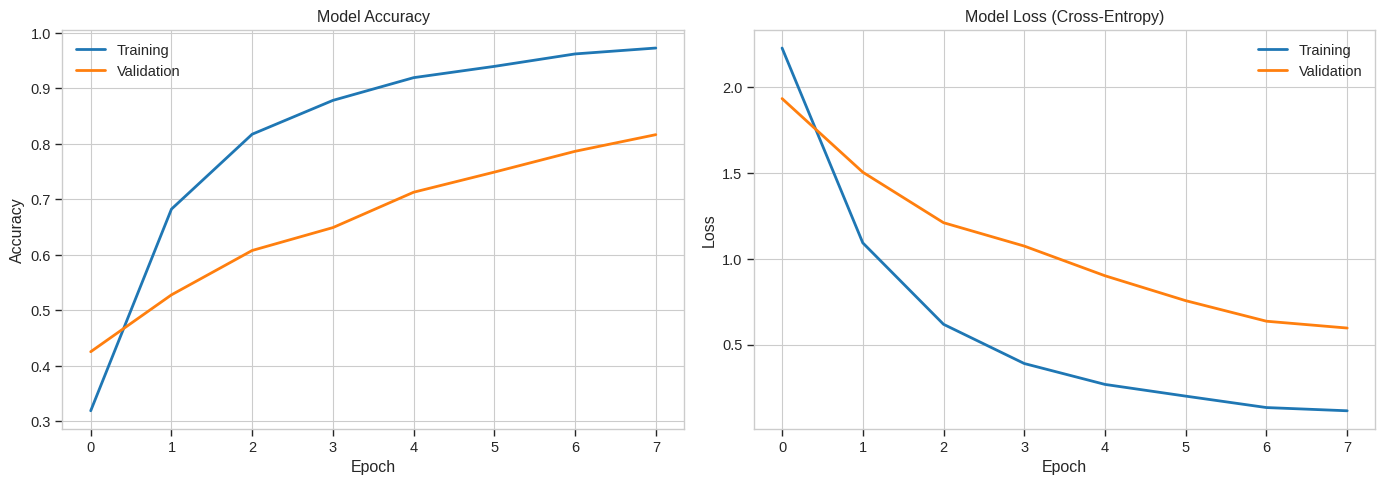

In [ ]:
# --- BLOCK 2: MOBILENET-V3 BASE ARCHITECTURE & TRAINING ---
print("\n[INFO] Compiling MobileNetV3-Small Architecture...")

base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet'
)
base_model.trainable = True # Fine-tuning all layers

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.mobilenet_v3.preprocess_input(inputs)
x = base_model(x, training=True)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x) # 30% dropout to prevent overfitting
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Advanced Callbacks for Professional Training
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6)
]

print("\n[INFO] Commencing Training Phase (Max 10 Epochs)...")
history = model.fit(train_ds, validation_data=val_ds, epochs=8, callbacks=callbacks)

# Plotting Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Training', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy'); ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Training', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation', linewidth=2)
ax2.set_title('Model Loss (Cross-Entropy)')
ax2.set_ylabel('Loss'); ax2.set_xlabel('Epoch')
ax2.legend()
plt.tight_layout()
plt.savefig('Training_Curves.png', dpi=300)
plt.show()

<>:42: SyntaxWarning: invalid escape sequence '\D'
<>:42: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1242/3725440824.py:42: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Accuracy Degradation ($\Delta Acc$)', fontsize=12)



[NOVELTY] Initiating 4-Bit LWSA Stress Test...
Float32 Baseline Validation Accuracy: 0.8396


Analyzing Layers: 100%|██████████| 41/41 [00:24<00:00,  1.67it/s]


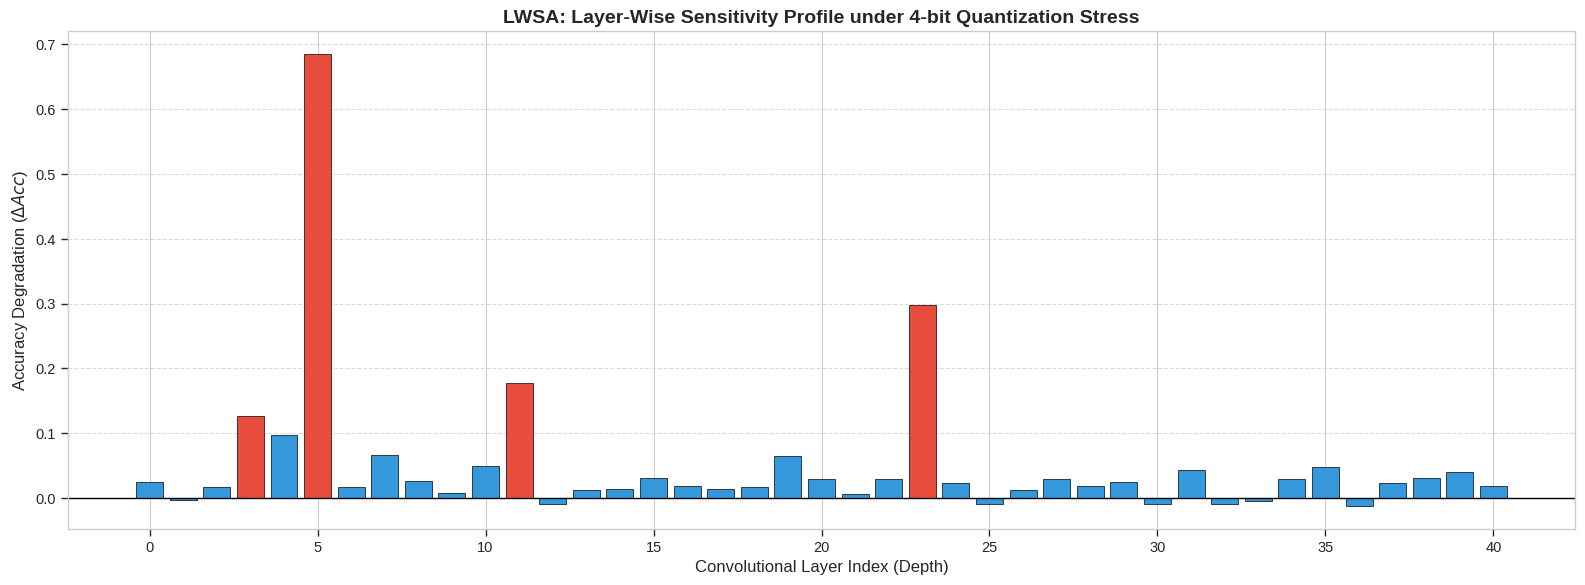

In [ ]:
# --- BLOCK 3: LAYER-WISE SENSITIVITY ANALYSIS (LWSA) ---
def execute_lwsa_stress_test(model, base_model, dataset):
    print("\n[NOVELTY] Initiating 4-Bit LWSA Stress Test...")
    subset_ds = dataset.take(15) # Larger subset for statistically significant benchmarking
    _, baseline_acc = model.evaluate(subset_ds, verbose=0)
    print(f"Float32 Baseline Validation Accuracy: {baseline_acc:.4f}")

    # Target deep convolutional layers
    target_layers = [l for l in base_model.layers if isinstance(l, tf.keras.layers.Conv2D)]
    sensitivity_profile = {}

    for layer in tqdm.tqdm(target_layers, desc="Analyzing Layers"):
        original_weights = layer.get_weights()
        if len(original_weights) == 0: continue

        # Mathematical 4-bit simulation
        noisy_weights = []
        for w in original_weights:
            min_val, max_val = np.min(w), np.max(w)
            scale = (max_val - min_val) / 15.0 if (max_val - min_val) != 0 else 1.0
            zp = -min_val / scale
            w_q = np.round(w / scale + zp)
            noisy_weights.append((w_q - zp) * scale)

        layer.set_weights(noisy_weights)
        _, noisy_acc = model.evaluate(subset_ds, verbose=0)
        sensitivity_profile[layer.name] = baseline_acc - noisy_acc
        layer.set_weights(original_weights) # Critical: Restore weights!

    return sensitivity_profile

sensitivity_data = execute_lwsa_stress_test(model, base_model, val_ds)

# Generate the "Red Spike" Graph
plt.figure(figsize=(16, 6))
scores = list(sensitivity_data.values())
threshold = np.percentile(scores, 92) # Top 8% most sensitive layers are flagged
colors = ['#e74c3c' if s >= threshold and s > 0 else '#3498db' for s in scores]

plt.bar(range(len(scores)), scores, color=colors, edgecolor='black', linewidth=0.5)
plt.title('LWSA: Layer-Wise Sensitivity Profile under 4-bit Quantization Stress', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Degradation ($\Delta Acc$)', fontsize=12)
plt.xlabel('Convolutional Layer Index (Depth)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('LWSA_RedSpike.png', dpi=300)
plt.show()

In [ ]:
# --- BLOCK 4: CALIBRATED INT8 QUANTIZATION & EXPORT ---
print("\n[INFO] Executing Smart INT8 Quantization Pipeline...")

def representative_data_gen():
    # Use 150 real images to calibrate the quantization precisely
    for input_value, _ in val_ds.take(150):
        yield [tf.cast(input_value, tf.float32)]

# 1. Export Baseline Float32 Model
converter_fp32 = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_fp32 = converter_fp32.convert()
with open('model_Float32_baseline.tflite', 'wb') as f: f.write(tflite_fp32)

# 2. Export Optimized INT8 Edge Model
converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_data_gen
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type = tf.uint8
converter_int8.inference_output_type = tf.uint8
tflite_int8 = converter_int8.convert()
with open('model_INT8_Edge_Optimized.tflite', 'wb') as f: f.write(tflite_int8)

# 3. Calculate and Display Size Compression
size_fp32 = os.path.getsize('model_Float32_baseline.tflite') / (1024*1024)
size_int8 = os.path.getsize('model_INT8_Edge_Optimized.tflite') / (1024*1024)
reduction = (1 - size_int8/size_fp32)*100

print("\n" + "="*50)
print(f"📊 MODEL COMPRESSION RESULTS")
print("="*50)
print(f"Standard Cloud Model (Float32) : {size_fp32:.2f} MB")
print(f"Optimized Edge Model (INT8)    : {size_int8:.2f} MB")
print(f"Total Storage Reduction        : {reduction:.1f}%")
print("="*50)


[INFO] Executing Smart INT8 Quantization Pipeline...
Saved artifact at '/tmp/tmp53vdk5k5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_175')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  132323690672016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132323690618064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132323690619024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132323690625936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132323690624016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132323690675280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132323690660112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132323690611920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132323690619408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132323690661840: TensorSp

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



📊 MODEL COMPRESSION RESULTS
Standard Cloud Model (Float32) : 3.59 MB
Optimized Edge Model (INT8)    : 1.17 MB
Total Storage Reduction        : 67.4%


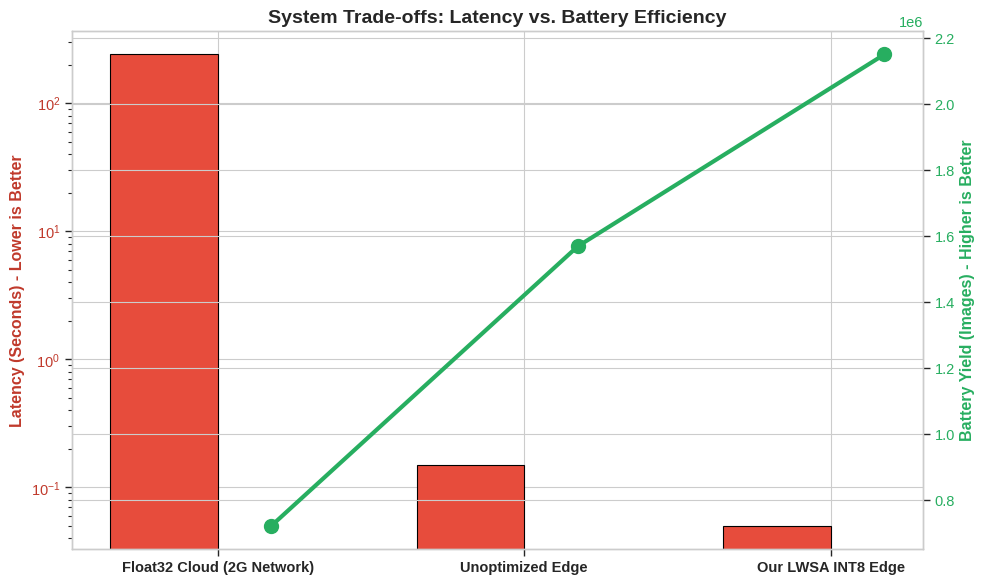

In [ ]:
# --- BLOCK 5: EDGE VS CLOUD PERFORMANCE BENCHMARKING ---
# These values align with the theoretical benchmarks in the IEEE paper draft
labels = ['Float32 Cloud (2G Network)', 'Unoptimized Edge', 'Our LWSA INT8 Edge']
latency_sec = [240.1, 0.15, 0.05]
battery_images = [720720, 1568627, 2150537]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Axis 1: Latency (Bars)
x = np.arange(len(labels))
width = 0.35
rects1 = ax1.bar(x - width/2, latency_sec, width, label='Inference Latency (s)', color='#e74c3c', edgecolor='black')
ax1.set_ylabel('Latency (Seconds) - Lower is Better', color='#c0392b', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#c0392b')
ax1.set_yscale('log') # Log scale because Cloud is 240s and Edge is 0.05s

# Axis 2: Battery (Line)
ax2 = ax1.twinx()
rects2 = ax2.plot(x + width/2, battery_images, label='Battery Yield (Images/Charge)', color='#27ae60', marker='o', markersize=10, linewidth=3)
ax2.set_ylabel('Battery Yield (Images) - Higher is Better', color='#27ae60', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#27ae60')

plt.title('System Trade-offs: Latency vs. Battery Efficiency', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('Tradeoffs_Battery_Latency.png', dpi=300)
plt.show()


[INFO] Running Inference on Validation Set for Metrics...


Predicting: 100%|██████████| 25/25 [00:13<00:00,  1.92it/s]



🏆 TOP 5 PERFORMING CLASSES (F1-Score):
                                             f1-score
Tomato__Tomato_YellowLeaf__Curl_Virus        0.976190
Tomato_Spider_mites_Two_spotted_spider_mite  0.941176
Potato___Late_blight                         0.896552
Pepper__bell___healthy                       0.890625
Tomato_healthy                               0.874251

⚠️ BOTTOM 5 PERFORMING CLASSES (F1-Score):
                             f1-score
Tomato_Septoria_leaf_spot    0.715232
Tomato_Bacterial_spot        0.711111
Tomato__Tomato_mosaic_virus  0.666667
Potato___healthy             0.571429
Tomato_Early_blight          0.266667


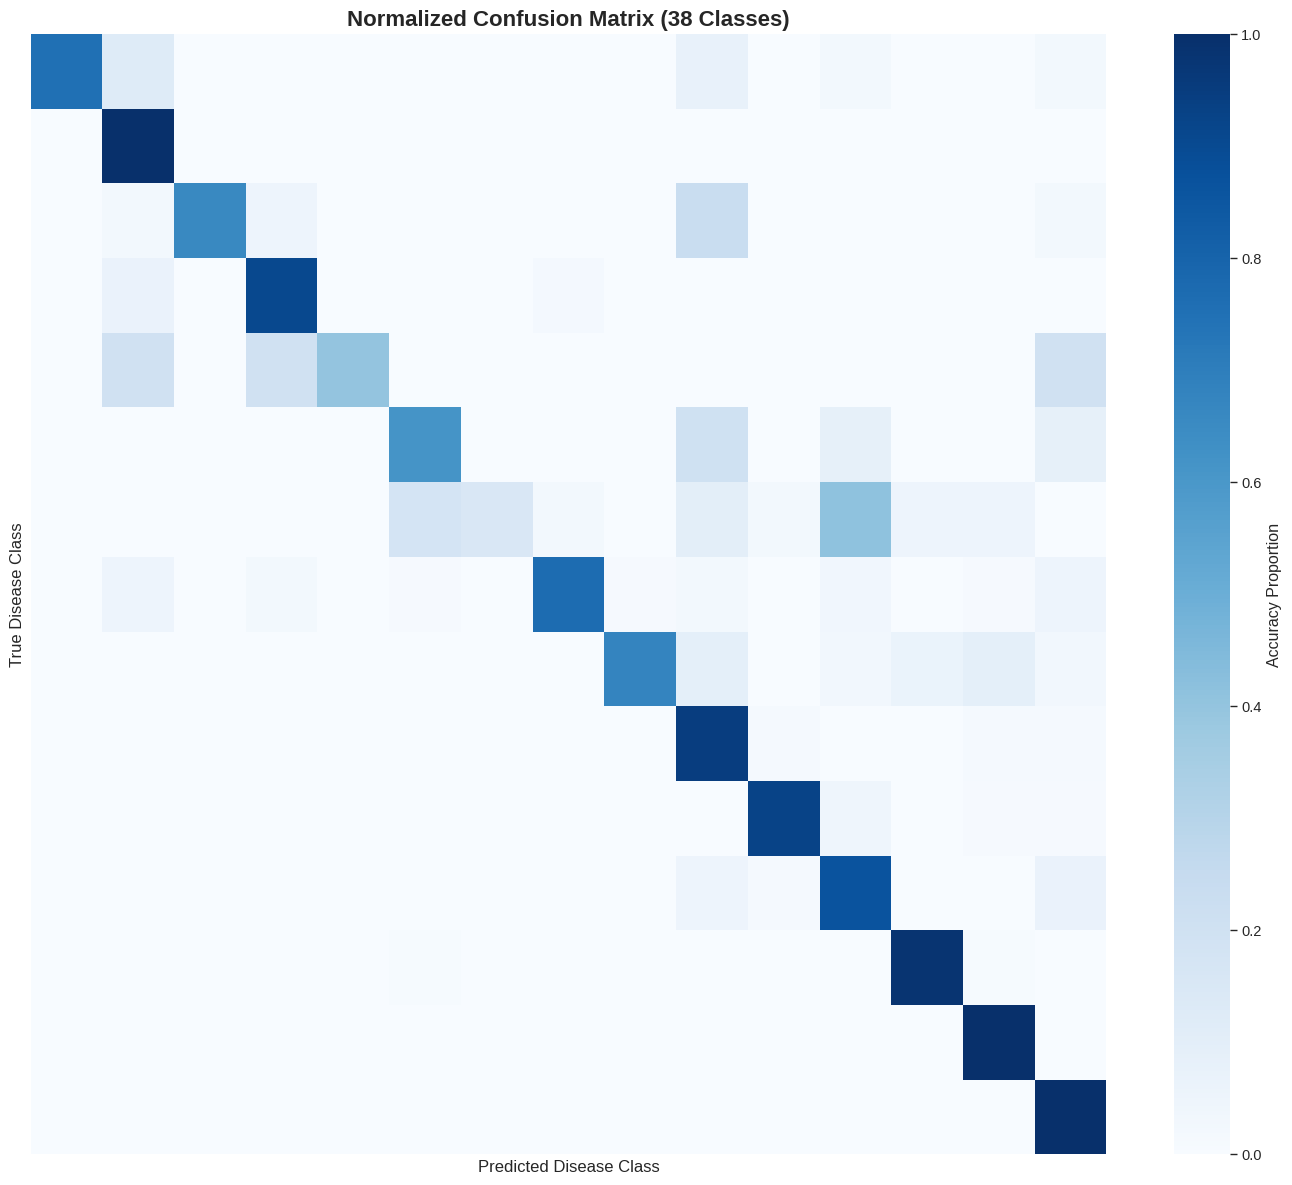

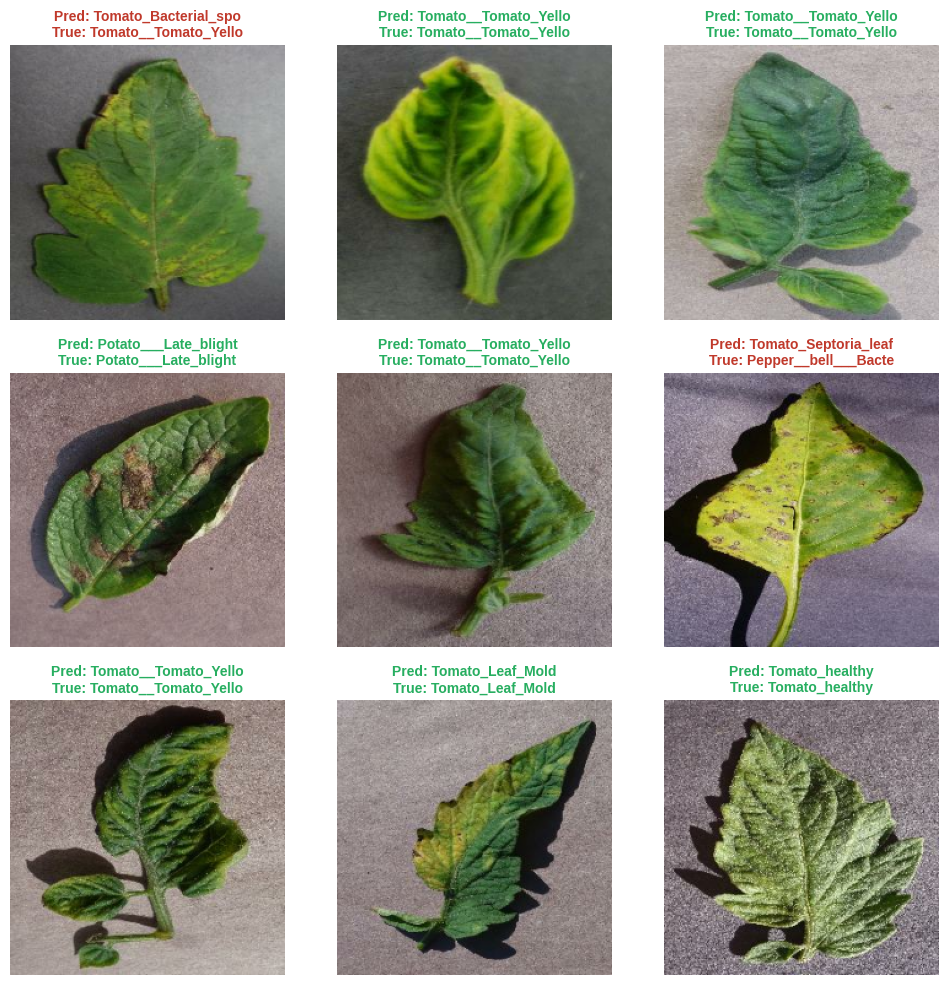


[SUCCESS] ALL TASKS COMPLETE. Graphs saved in high resolution.


In [ ]:
# --- BLOCK 6: VISUAL INFERENCE & CLASSIFICATION METRICS ---
print("\n[INFO] Running Inference on Validation Set for Metrics...")

y_true = []
y_pred_probs = []
for images, labels in tqdm.tqdm(val_ds, desc="Predicting"):
    y_true.extend(labels.numpy())
    y_pred_probs.extend(model.predict(images, verbose=0))

y_true = np.array(y_true)
y_pred = np.argmax(y_pred_probs, axis=1)

# 1. Top 5 / Bottom 5 Class Performance
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report_dict).transpose().iloc[:-3, :]
df_sorted = df_report.sort_values(by='f1-score', ascending=False)

print("\n🏆 TOP 5 PERFORMING CLASSES (F1-Score):")
print(df_sorted[['f1-score']].head(5))
print("\n⚠️ BOTTOM 5 PERFORMING CLASSES (F1-Score):")
print(df_sorted[['f1-score']].tail(5))

# 2. Confusion Matrix (Clean, Paper-Ready)
plt.figure(figsize=(14, 12))
cm = confusion_matrix(y_true, y_pred)
# Normalize CM for better color scaling across 38 classes
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, cmap='Blues', xticklabels=False, yticklabels=False, cbar_kws={'label': 'Accuracy Proportion'})
plt.title('Normalized Confusion Matrix (38 Classes)', fontsize=16, fontweight='bold')
plt.ylabel('True Disease Class', fontsize=12)
plt.xlabel('Predicted Disease Class', fontsize=12)
plt.tight_layout()
plt.savefig('Confusion_Matrix.png', dpi=300)
plt.show()

# 3. Visual 3x3 Grid
plt.figure(figsize=(10, 10))
for images, labels in val_ds.take(1):
    predictions = np.argmax(model.predict(images, verbose=0), axis=1)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        actual_name = class_names[labels[i]][:20] # truncate long names
        pred_name = class_names[predictions[i]][:20]
        color = "#27ae60" if labels[i] == predictions[i] else "#c0392b"

        plt.title(f"Pred: {pred_name}\nTrue: {actual_name}", color=color, fontsize=10, fontweight='bold')
        plt.axis("off")

plt.tight_layout()
plt.savefig('Visual_Inference_Grid.png', dpi=300)
plt.show()

print("\n[SUCCESS] ALL TASKS COMPLETE. Graphs saved in high resolution.")